# LII Congreso Nacional de Psicología CNEIP 2026
# Métodos para Analizar Oscilaciones Neuronales y Actividad Aperiódica

La primera parte del taller (Procesamiento de Señales Digitales y Simulaciones) consta de 2 partes separadas en 2 notebooks. En el primer notebook aprendiste cómo cambian los espectros de potencia (power spectra) según la señal temporal simulada. El segundo notebook (este) explorará los fundamentos del filtrado (filtering) y cómo este puede alterar tus datos, para que puedas tenerlo en cuenta en tus propios análisis. A continuación se presentan los temas considerados en este notebook:

- Fundamentos del filtrado (filtering)
    - oscilaciones sinusoidales
    - oscilaciones no sinusoidales
- Filtrar una señal simulada realista

## Lección 2: Procesamiento de Señales Digitales - filtrado (filtering) de datos simulados y reales

En este notebook revisaremos algunas funciones para simular tus propios datos usando la librería NeuroDSP
(https://neurodsp-tools.github.io/neurodsp/index.html)

### Preparación

In [1]:
# Instalar paquetes necesarios (para Colab)
!pip install neurodsp

#### Paquetes

In [2]:
# general 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# herramientas del Voytek Lab
from neurodsp import spectral
from neurodsp import filt
from neurodsp import sim
from neurodsp import utils
from neurodsp import plts

#### Configuración

In [3]:
# parámetros de la señal
N_SECONDS = 100 # duración de la señal
FS = 1000 # frecuencia de muestreo

In [4]:
# parámetros de graficación

# tamaño de fuente
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 10

# color
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['axes.facecolor'] = 'w'

#### Funciones

In [5]:
def plot_signal_and_power(time, signal, freq, spectrum, title='', logscale=False, xlims=None):
    '''
    Grafica una serie temporal y su espectro de potencia (power spectrum) correspondiente

    Parámetros
    ----------
    time : arreglo 1D, float
        vector temporal de la señal
    signal : arreglo 1D, float
        serie temporal, por ejemplo LFP o EEG
    freq : arreglo 1D, float
        vector de frecuencias del spectrum
    spectrum : arreglo 1D, float
        espectro de potencia (power spectrum) de la señal
    title : str, opcional
        título de la figura. El valor predeterminado es ''.
    logscale : bool, opcional
        indica si se grafica el spectrum en espacio log-log. El valor predeterminado es False.
    xlims : arreglo 1D (len=2), opcional
        límites del eje x para la gráfica de la serie temporal ([límite_inferior, límite_superior]). 
        El valor predeterminado es None.

    '''
    # crear figura
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=[12,4], gridspec_kw={'width_ratios': [3, 1]}, constrained_layout=True)
    fig.suptitle(title)

    # graficar señal
    ax1.set(xlabel='time (s)', ylabel='voltage (au)', title='Time-series')
    ax1.plot(time, signal)
    if xlims:
        ax1.set_xlim(xlims)
        
    # graficar spectra
    ax2.set(xlabel='frequency (Hz)', ylabel='power (au)', title='Power Spectral Density')
    ax2.plot(freq, spectrum);
    ax2.set_xlim([.1,200])
    if logscale:
        ax2.set(xscale='log', yscale='log')


### Fundamentos del filtrado (filtering)
Antes que nada, ¿qué es el filtrado? Una sola señal puede contener muchas oscilaciones. El objetivo de filtrar tus datos es eliminar frecuencias no deseadas (como el ruido de línea) o aislar la banda de frecuencia de interés para análisis posteriores.

Comencemos con un ejemplo que contiene 2 oscilaciones (del notebook anterior):

In [6]:
# configuración
freq_oscillations = [5, 60] # frecuencia pico de la oscilación
osc_amp = [1, 0.5] # amplitud de la oscilación

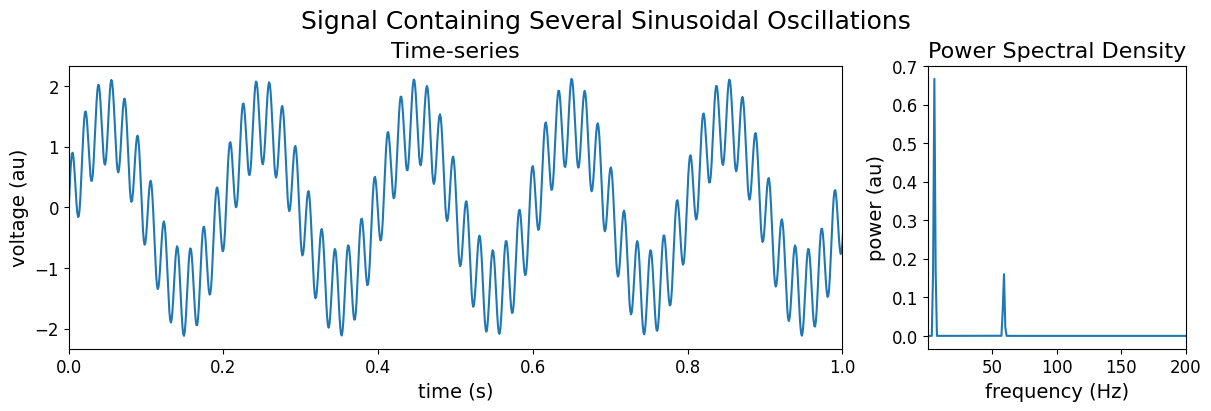

In [7]:
# simular señal
time = utils.create_times(N_SECONDS, FS)
signal_sins = np.zeros_like(time)

for i_osc in range(len(freq_oscillations)):
    signal_sins += sim.sim_oscillation(N_SECONDS, FS, freq_oscillations[i_osc]) * osc_amp[i_osc]

# calcular espectro de potencia
freq, psd_sins = spectral.compute_spectrum(signal_sins, FS)

# graficar
plot_signal_and_power(time, signal_sins, freq, psd_sins, 
    title='Signal Containing Several Sinusoidal Oscillations', xlims=[0,1])

Esta señal está compuesta por dos ondas sinusoidales que oscilan a diferentes frecuencias: una onda de baja frecuencia y alta amplitud, y otra de alta frecuencia y baja amplitud. Podemos usar un filtro para obtener solo un componente de esta onda compleja e ignorar todo lo demás. El filtro que usaremos se conoce como un tipo de filtro band-pass. Su objetivo es conservar solo las frecuencias dentro de un rango especificado.

Usaremos una función de NeuroDSP [(filter_signal)](https://neurodsp-tools.github.io/neurodsp/generated/neurodsp.filt.filter_signal.html). 

Existen muchos tipos de filtros y ninguno es perfecto. Cada filtro tiene ventajas y desventajas, y esos detalles son importantes, pero no se cubrirán aquí a profundidad. 

La función de filtrado de neuroDSP requiere un mínimo de 2 parámetros para describir el filtro:

    pass_type: indica el tipo de filtro (en nuestro caso, bandpass)
    f_range: indica el rango de frecuencias que se conservará

A continuación se muestran algunas funciones que nos permiten usar el filtro Butterworth. Por ahora ignoraremos los detalles de estas funciones, ya que lo más importante no es cómo crear un filtro, sino entender por qué lo usamos.

In [8]:
# filtrar oscilaciones en la señal
low_freq = filt.filter_signal(signal_sins, fs=FS, pass_type='bandpass', f_range=(2, 7))
high_freq = filt.filter_signal(signal_sins, fs=FS, pass_type='bandpass', f_range=(50, 70))

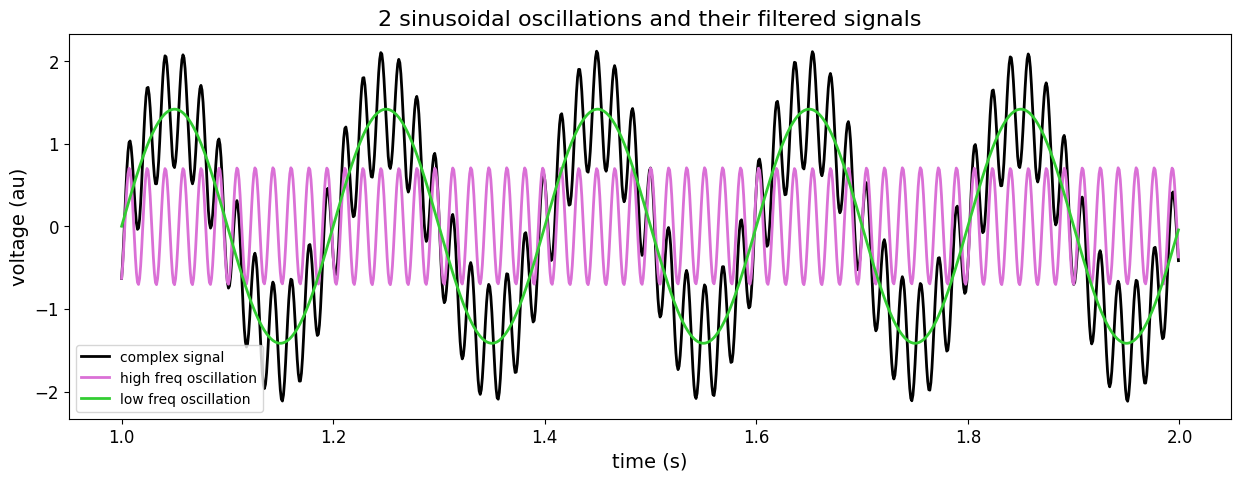

In [9]:
# graficar las señales y las señales filtradas en la misma gráfica
plt.figure(figsize=(15,5))
plt.plot(time[1000:2000], signal_sins[1000:2000], color='black', lw=2, label='complex signal')
plt.plot(time[1000:2000], high_freq[1000:2000], color='orchid', lw=2, label='high freq oscillation')
plt.plot(time[1000:2000], low_freq[1000:2000], color='limegreen', lw=2, label='low freq oscillation')

plt.xlabel('time (s)')
plt.ylabel('voltage (au)')

plt.legend()
plt.title('2 sinusoidal oscillations and their filtered signals')
plt.show()

### Filtrado (filtering) de señales no sinusoidales

Usemos las mismas frecuencias de antes, pero esta vez crearemos oscilaciones no sinusoidales agregando los argumentos "cycle" y "width". Con una forma sawtooth, un valor de width de 0.5 produce una forma triangular. Un valor menor produce un ascenso más agudo y un valor mayor produce una caída más aguda.

Puedes ver cómo cambia el espectro de potencia (power spectrum) al modificar esos números.

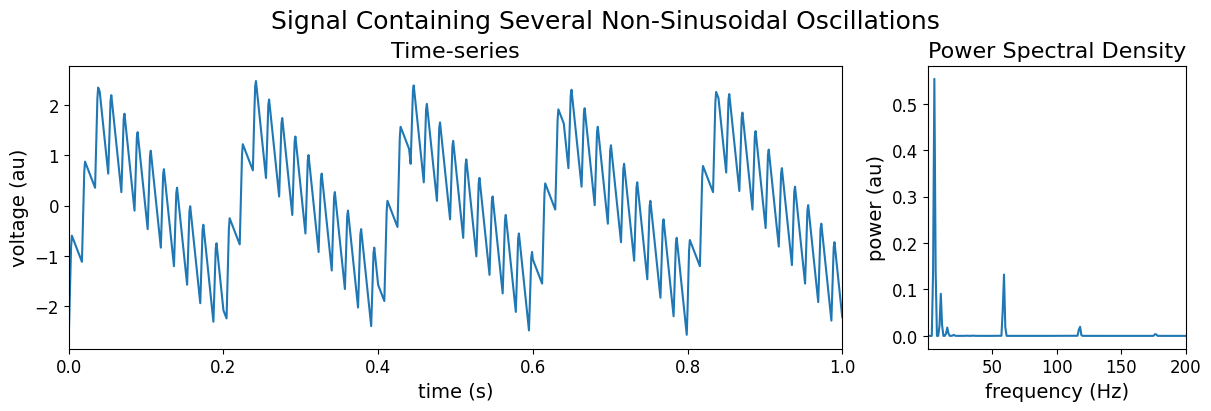

In [10]:
# simular señal
time = utils.create_times(N_SECONDS, FS)
signal_saw = np.zeros_like(time)

CYCLE = 'sawtooth'
WIDTH = 0.2


for i_osc in range(len(freq_oscillations)):
    signal_saw += sim.sim_oscillation(N_SECONDS, FS, freq_oscillations[i_osc], 
                                       cycle=CYCLE, width=WIDTH) * osc_amp[i_osc]

# calcular espectro de potencia
freq, psd_sins = spectral.compute_spectrum(signal_saw, FS)

# graficar
plot_signal_and_power(time, signal_saw, freq, psd_sins, 
    title='Signal Containing Several Non-Sinusoidal Oscillations', xlims=[0,1])

In [11]:
# filtrar oscilaciones en la señal
low_freq = filt.filter_signal(signal_saw, fs=FS, pass_type='bandpass', f_range=(2, 7))
high_freq = filt.filter_signal(signal_saw, fs=FS, pass_type='bandpass', f_range=(50, 70))

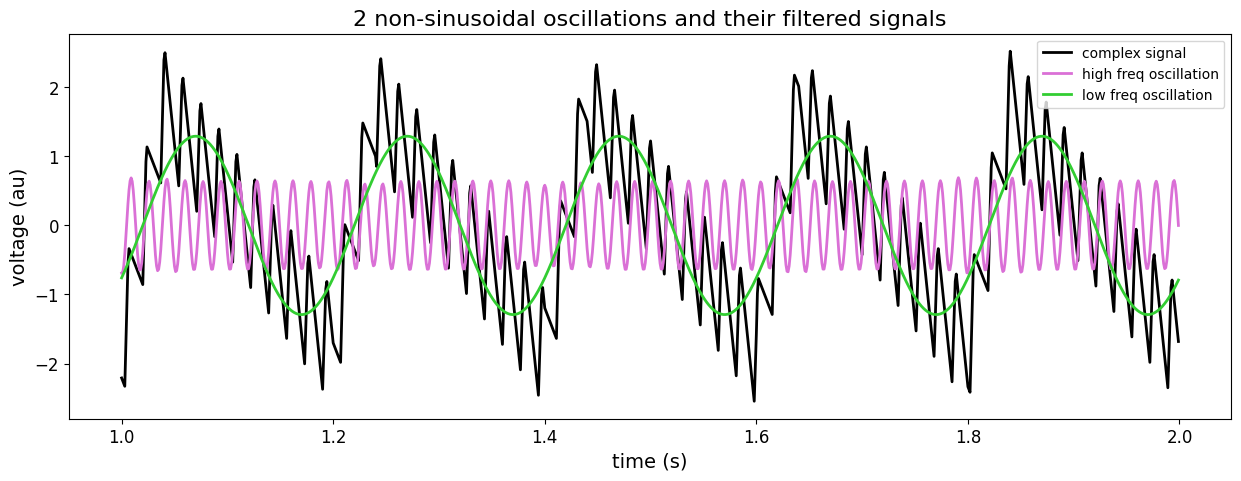

In [12]:
# graficar las señales y las señales filtradas en la misma gráfica
plt.figure(figsize=(15,5))
plt.plot(time[1000:2000], signal_saw[1000:2000], color='black', lw=2, label='complex signal')
plt.plot(time[1000:2000], high_freq[1000:2000], color='orchid', lw=2, label='high freq oscillation')
plt.plot(time[1000:2000], low_freq[1000:2000], color='limegreen', lw=2, label='low freq oscillation')

plt.xlabel('time (s)')
plt.ylabel('voltage (au)')

plt.legend()
plt.title('2 non-sinusoidal oscillations and their filtered signals')
plt.show()

## Filtrar una señal simulada realista

In [13]:
# fijar la semilla aleatoria para generar datos simulados de forma consistente
utils.set_random_seed(0)

# fijar algunas configuraciones generales para usar en todas las simulaciones
FS = 1000
N_SECONDS = 3
TIMES = utils.create_times(N_SECONDS, FS)

In [14]:
# definir los componentes de la señal combinada que se va a simular
components = {'sim_synaptic_current' : {'n_neurons' : 1000, 'firing_rate' : 2, 't_ker' : 1.0,
                                        'tau_r' : 0.002, 'tau_d' : 0.02},
              'sim_oscillation' : {'freq' : 8}}
component_variances = [1, 0.7] # varianza usada para simular cada componente de la señal

In [15]:
# simular una oscilación periódica sobre un componente aperiódico
per_aper_sig = sim.combined.sim_combined(N_SECONDS, FS, components, component_variances)

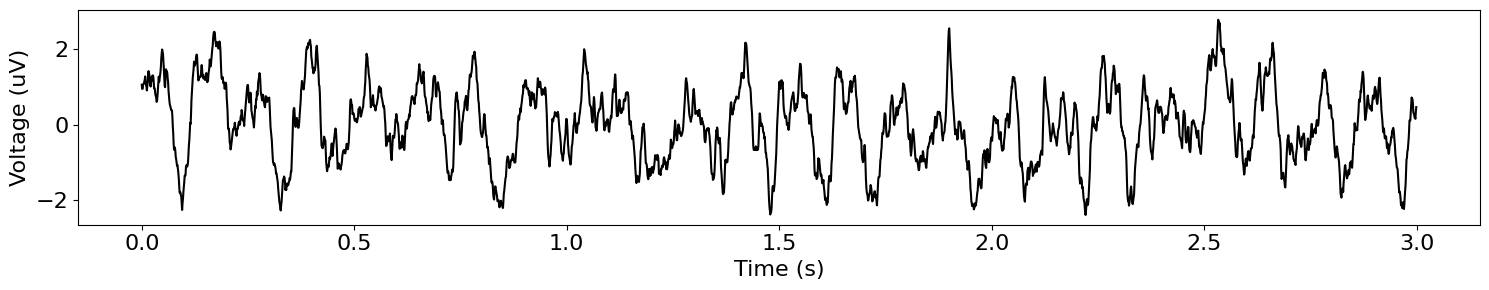

In [16]:
# graficar los datos simulados en el dominio temporal
plts.time_series.plot_time_series(TIMES, per_aper_sig)

In [17]:
# filtrar señal
filt_signal = filt.filter_signal(per_aper_sig, fs=FS, pass_type='bandpass', f_range=(6, 10))

In [18]:
# encontrar picos en la señal
peaks_raw, _ = find_peaks(per_aper_sig, distance=100)
peaks_filt, _ = find_peaks(filt_signal, distance=100)

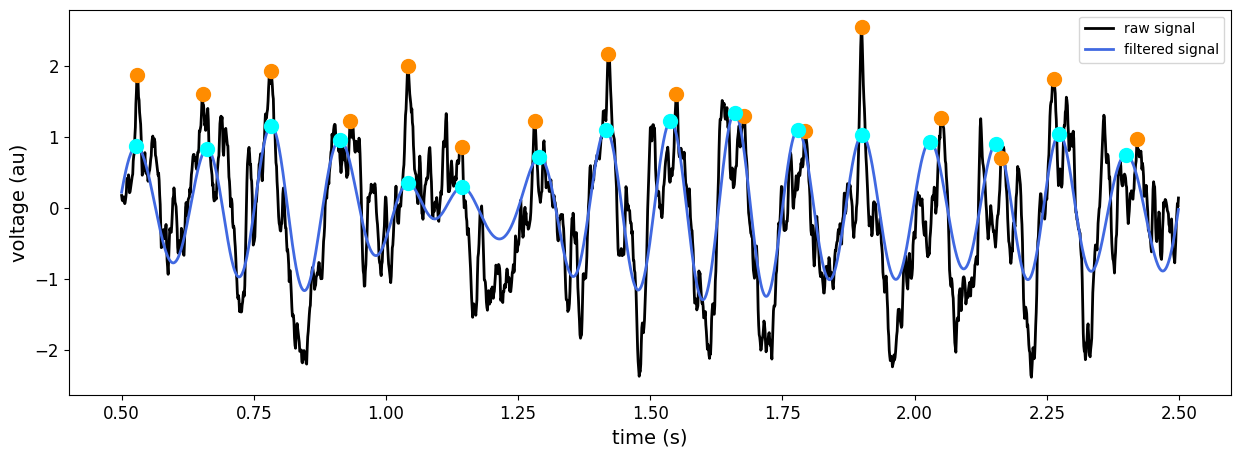

In [19]:
# graficar las señales y las señales filtradas en la misma gráfica
CROP_LO = 500
CROP_HI = -500

plt.figure(figsize=(15,5))
plt.plot(TIMES[CROP_LO:CROP_HI], per_aper_sig[CROP_LO:CROP_HI], color='black', lw=2, label='raw signal')
plt.plot(TIMES[CROP_LO:CROP_HI], filt_signal[CROP_LO:CROP_HI], color='royalblue', lw=2, label='filtered signal')

for peak in peaks_raw:
    if peak > 500 and peak < 2500:
        plt.plot(TIMES[peak], per_aper_sig[peak], marker='.', markersize=20, color='darkorange')

for peak in peaks_filt:
    if peak > 500 and peak < 2500:
        plt.plot(TIMES[peak], filt_signal[peak], marker='.', markersize=20, color='cyan')

plt.xlabel('time (s)')
plt.ylabel('voltage (au)')

plt.legend()
plt.show()

### Conclusion

Como puedes ver en la figura anterior, los picos naranjas (de la señal original) no se alinean perfectamente con los picos cian (de la señal filtrada). Algunos de los picos filtrados tienen una amplitud mucho menor que los picos originales y otros están desplazados en el tiempo, por lo que no capturan las asimetrías de la señal.

Esto demuestra la pérdida de información que ocurre al filtrar datos originales que presentan características no sinusoidales variables.